# 01 — Hill Climbing for Seismic Velocity Picking

Hill Climbing is the simplest local search heuristic. It starts from a
random solution and iteratively moves to better neighbors until no
improvement is found.

In this context:
- **Solution**: a set of (time, velocity) pairs along a CDP
- **Objective function**: semblance coherence (higher = better)
- **Neighbor**: a solution with one pick slightly perturbed

This notebook serves as the **baseline** for comparison with
more advanced metaheuristics.

**Execution order:**
1. Setup and imports
2. Generate synthetic CDP gather from Marmousi2
3. Compute and visualize semblance
4. Run Hill Climbing
5. Visualize result
6. Evaluate metrics
7. Save results

## 1. Setup

In [1]:
import sys
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# Project root
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f'Project root: {project_root}')

Project root: /home/rafae/projetos/seismic-velocity-picking


In [2]:
from src.seismic.io        import load_marmousi2_velocity
from src.seismic.synthetic import generate_cdp_gather
from src.seismic.semblance import compute_semblance
from src.optimizers.hill_climbing import HillClimbing

print('All modules imported successfully.')

All modules imported successfully.


## 2. Parameters

In [3]:
# --- Acquisition parameters ---
CDP_IDX      = 6800          # CDP to analyze
N_OFFSETS    = 50            # number of receivers
OFFSET_MIN_M = 100.0         # minimum offset in meters
OFFSET_MAX_M = 3000.0        # maximum offset in meters
DT_MS        = 2.0           # time sampling in ms
T_MAX_MS     = 3000.0        # max record time in ms
F0_HZ        = 30.0          # Ricker wavelet frequency
NOISE_LEVEL  = 0.05          # Gaussian noise amplitude

# --- Semblance parameters ---
VEL_MIN      = 1400.0        # min velocity for semblance scan (m/s)
VEL_MAX      = 3000.0        # max velocity for semblance scan (m/s)
VEL_STEP     = 30.0          # velocity increment (m/s)

# --- Hill Climbing parameters ---
N_PICKS      = 10            # number of picks to find
MAX_ITER     = 300           # iterations per restart
RESTARTS     = 5             # number of random restarts
STEP_TIME    = 5             # max time perturbation (samples)
STEP_VEL     = 50.0          # max velocity perturbation (m/s)
N_NEIGHBORS  = 30            # neighbors evaluated per iteration
SEED         = 42

print('Parameters set.')

Parameters set.


## 3. Generate synthetic CDP gather

In [4]:
MARMOUSI_DIR = os.path.join(project_root, 'data', 'models', 'marmousi2')

vel_model, info = load_marmousi2_velocity(MARMOUSI_DIR, verbose=False)

vel_profile = vel_model[CDP_IDX, :]
offsets_m   = np.linspace(OFFSET_MIN_M, OFFSET_MAX_M,
                          N_OFFSETS, dtype=np.float32)

gather, t_grid, v_rms_true = generate_cdp_gather(
    vel_profile,
    spacing_m   = info['spacing_m'],
    offsets_m   = offsets_m,
    dt_ms       = DT_MS,
    t_max_ms    = T_MAX_MS,
    f0_hz       = F0_HZ,
    noise_level = NOISE_LEVEL,
    seed        = SEED
)

print(f'Gather shape  : {gather.shape}')
print(f'T max         : {t_grid[-1]:.1f} ms')
print(f'V RMS range   : {v_rms_true.min():.1f} — {v_rms_true.max():.1f} m/s')

Gather shape  : (50, 1501)
T max         : 3000.0 ms
V RMS range   : 1500.0 — 2510.8 m/s


## 4. Compute semblance

In [5]:
velocidades = np.arange(VEL_MIN, VEL_MAX + VEL_STEP,
                        VEL_STEP, dtype=np.float32)

print('Computing semblance...')
semblance = compute_semblance(gather, offsets_m, velocidades, dt_ms=DT_MS)
print(f'Semblance shape: {semblance.shape}  (n_vel x n_samples)')
print(f'Max semblance  : {semblance.max():.4f}')

Computing semblance...
Semblance shape: (55, 1501)  (n_vel x n_samples)
Max semblance  : 0.9980


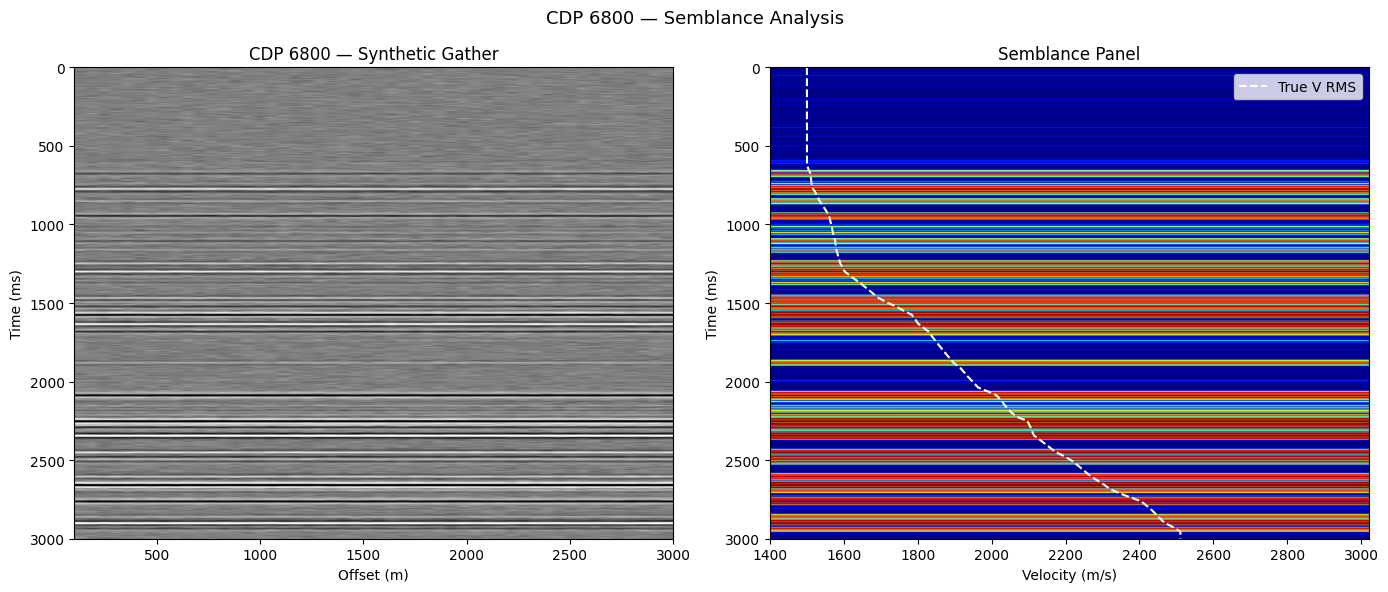

Figure saved.


In [6]:
os.makedirs(os.path.join(project_root, 'results', 'figures'), exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# CDP gather
vmax = np.percentile(np.abs(gather), 98)
axes[0].imshow(
    gather.T, aspect='auto', cmap='gray',
    vmin=-vmax, vmax=vmax,
    extent=[offsets_m[0], offsets_m[-1], t_grid[-1], t_grid[0]]
)
axes[0].set_xlabel('Offset (m)')
axes[0].set_ylabel('Time (ms)')
axes[0].set_title(f'CDP {CDP_IDX} — Synthetic Gather')

# Semblance
axes[1].imshow(
    semblance.T, aspect='auto', cmap='jet',
    vmin=0, vmax=1,
    extent=[velocidades[0], velocidades[-1], t_grid[-1], t_grid[0]]
)
axes[1].plot(v_rms_true, t_grid, 'w--', linewidth=1.5, label='True V RMS')
axes[1].set_xlabel('Velocity (m/s)')
axes[1].set_ylabel('Time (ms)')
axes[1].set_title('Semblance Panel')
axes[1].legend()

plt.suptitle(f'CDP {CDP_IDX} — Semblance Analysis', fontsize=13)
plt.tight_layout()
plt.savefig(
    os.path.join(project_root, 'results', 'figures',
                 '01_semblance_before_picking.png'), dpi=150
)
plt.show()
print('Figure saved.')

## 5. Run Hill Climbing

In [7]:
hc = HillClimbing(
    traces      = gather,
    offsets     = offsets_m,
    dt_ms       = DT_MS,
    vel_min     = VEL_MIN,
    vel_max     = VEL_MAX,
    n_picks     = N_PICKS,
    max_iter    = MAX_ITER,
    seed        = SEED,
    step_time   = STEP_TIME,
    step_vel    = STEP_VEL,
    n_neighbors = N_NEIGHBORS,
    restarts    = RESTARTS
)

print('Running Hill Climbing...')
hc.run()

times_pick, vels_pick = hc.get_result()

print(f'Execution time : {hc.exec_time_s:.2f} s')
print(f'Best score     : {hc.best_score:.4f}')
print()
print('Picks found (time_ms, velocity_m/s):')
for t, v in zip(times_pick * DT_MS, vels_pick):
    print(f'  t={t:7.1f} ms   v={v:.1f} m/s')

Running Hill Climbing...
Execution time : 145.14 s
Best score     : 0.8517

Picks found (time_ms, velocity_m/s):
  t=  776.0 ms   v=1400.0 m/s
  t=  852.0 ms   v=1400.0 m/s
  t=  946.0 ms   v=1402.5 m/s
  t= 1052.0 ms   v=1402.9 m/s
  t= 1370.0 ms   v=1429.4 m/s
  t= 1468.0 ms   v=1663.2 m/s
  t= 1880.0 ms   v=2436.4 m/s
  t= 2184.0 ms   v=2513.7 m/s
  t= 2658.0 ms   v=2645.4 m/s
  t= 2900.0 ms   v=2764.4 m/s


## 6. Visualize result

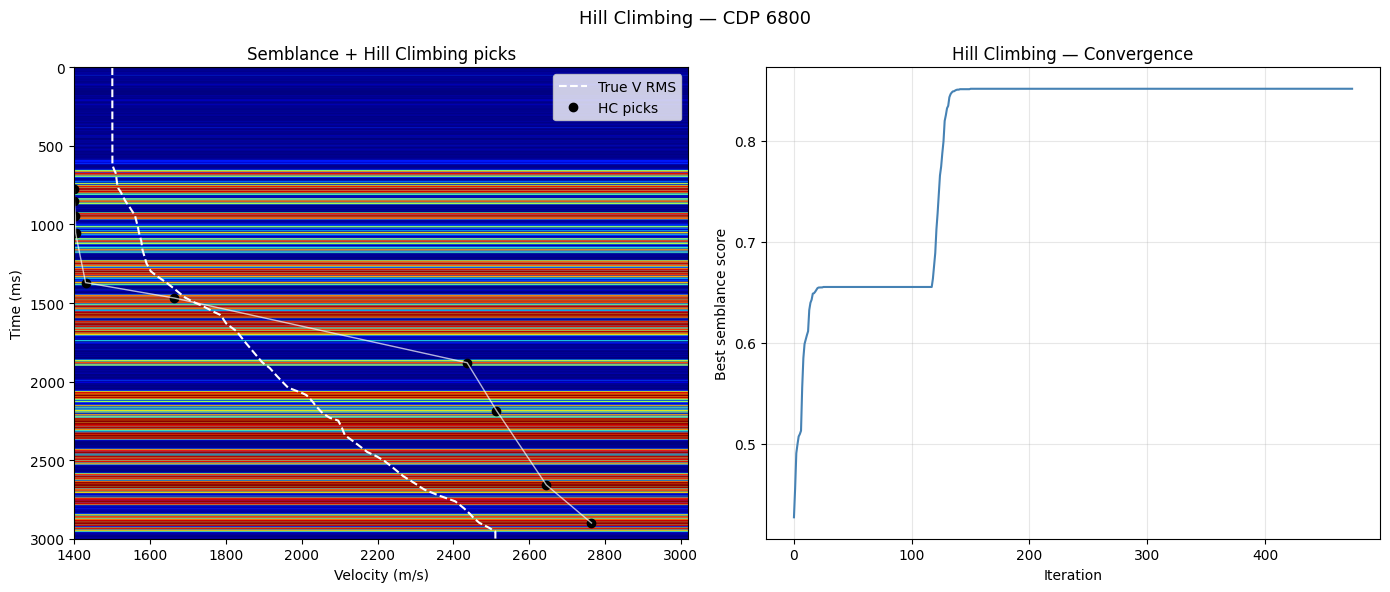

Figure saved.


In [8]:
# Convert pick times from samples to ms
times_ms = times_pick * DT_MS

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Semblance with picks overlaid
axes[0].imshow(
    semblance.T, aspect='auto', cmap='jet',
    vmin=0, vmax=1,
    extent=[velocidades[0], velocidades[-1], t_grid[-1], t_grid[0]]
)
axes[0].plot(v_rms_true, t_grid,
             'w--', linewidth=1.5, label='True V RMS')
axes[0].plot(vels_pick, times_ms,
             'ko', markersize=6, label='HC picks')
axes[0].plot(vels_pick, times_ms,
             'w-', linewidth=1.0, alpha=0.7)
axes[0].set_xlabel('Velocity (m/s)')
axes[0].set_ylabel('Time (ms)')
axes[0].set_title('Semblance + Hill Climbing picks')
axes[0].legend()

# Convergence curve
axes[1].plot(hc.history, color='steelblue', linewidth=1.5)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Best semblance score')
axes[1].set_title('Hill Climbing — Convergence')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Hill Climbing — CDP {CDP_IDX}', fontsize=13)
plt.tight_layout()
plt.savefig(
    os.path.join(project_root, 'results', 'figures',
                 '01_hill_climbing_result.png'), dpi=150
)
plt.show()
print('Figure saved.')

## 7. Metrics

In [9]:
# Interpolate true v_rms at pick times
v_true_at_picks = np.interp(times_ms, t_grid, v_rms_true)

rmse = np.sqrt(np.mean((vels_pick - v_true_at_picks) ** 2))
mae  = np.mean(np.abs(vels_pick - v_true_at_picks))
mape = np.mean(np.abs((vels_pick - v_true_at_picks) / v_true_at_picks)) * 100

print('=== Metrics ===')
print(f'RMSE : {rmse:.2f} m/s')
print(f'MAE  : {mae:.2f} m/s')
print(f'MAPE : {mape:.2f} %')
print(f'Time : {hc.exec_time_s:.2f} s')
print(f'Score: {hc.best_score:.4f}')

print()
print(f'{"Time (ms)":>12} {"Picked (m/s)":>14} {"True (m/s)":>12} {"Error (m/s)":>12}')
print('-' * 54)
for t, vp, vt in zip(times_ms, vels_pick, v_true_at_picks):
    err = vp - vt
    print(f'{t:12.1f} {vp:14.1f} {vt:12.1f} {err:+12.1f}')

=== Metrics ===
RMSE : 290.13 m/s
MAE  : 246.16 m/s
MAPE : 13.00 %
Time : 145.14 s
Score: 0.8517

   Time (ms)   Picked (m/s)   True (m/s)  Error (m/s)
------------------------------------------------------
       776.0         1400.0       1517.4       -117.4
       852.0         1400.0       1534.8       -134.8
       946.0         1402.5       1560.1       -157.6
      1052.0         1402.9       1570.3       -167.4
      1370.0         1429.4       1642.7       -213.3
      1468.0         1663.2       1694.2        -31.0
      1880.0         2436.4       1896.9       +539.4
      2184.0         2513.7       2047.9       +465.8
      2658.0         2645.4       2305.4       +340.0
      2900.0         2764.4       2469.5       +294.9


## 8. Save results

In [10]:
os.makedirs(os.path.join(project_root, 'results', 'metrics'), exist_ok=True)
os.makedirs(os.path.join(project_root, 'results', 'picks'),   exist_ok=True)

# Metrics
metrics = {
    'algorithm':   'HillClimbing',
    'cdp':         CDP_IDX,
    'rmse':        float(rmse),
    'mae':         float(mae),
    'mape':        float(mape),
    'best_score':  float(hc.best_score),
    'exec_time_s': float(hc.exec_time_s),
    'n_picks':     N_PICKS,
    'max_iter':    MAX_ITER,
    'restarts':    RESTARTS,
    'seed':        SEED,
}

metrics_path = os.path.join(project_root, 'results', 'metrics',
                            'hill_climbing.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

# Picks
picks_path = os.path.join(project_root, 'results', 'picks',
                          'hill_climbing.npy')
np.save(picks_path, {
    'times_ms':  times_ms,
    'vels_pick': vels_pick,
    'v_true':    v_true_at_picks,
})

# Convergence history
history_path = os.path.join(project_root, 'results', 'metrics',
                            'hill_climbing_history.npy')
np.save(history_path, np.array(hc.history))

print('Results saved:')
print(f'  Metrics    : {metrics_path}')
print(f'  Picks      : {picks_path}')
print(f'  History    : {history_path}')
print()
print(json.dumps(metrics, indent=2))

Results saved:
  Metrics    : /home/rafae/projetos/seismic-velocity-picking/results/metrics/hill_climbing.json
  Picks      : /home/rafae/projetos/seismic-velocity-picking/results/picks/hill_climbing.npy
  History    : /home/rafae/projetos/seismic-velocity-picking/results/metrics/hill_climbing_history.npy

{
  "algorithm": "HillClimbing",
  "cdp": 6800,
  "rmse": 290.1346801062035,
  "mae": 246.16455576692093,
  "mape": 12.997013382410175,
  "best_score": 0.8516819417476654,
  "exec_time_s": 145.137786979,
  "n_picks": 10,
  "max_iter": 300,
  "restarts": 5,
  "seed": 42
}


## 9. Summary

**Hill Climbing** is a greedy local search that accepts only improvements.
It is fast but prone to getting trapped in local optima.

**Limitations identified here:**
- Sensitive to the initial solution
- Multiple restarts help but do not guarantee global optimum
- No mechanism to escape local optima

**Next notebooks:**
- `02_tabu_search` — adds memory to avoid revisiting solutions
- `03_tabu_sa_hybrid` — adds probabilistic acceptance to escape local optima